In [1]:
import os
import re
from glob import glob
import imageio
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from pprint import pprint
from tqdm import tqdm
import torch
import pickle
from xgboost import XGBClassifier
from xgboost import plot_tree
import xgboost

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics 

import dtreeviz
from dtreeviz import trees
from dtreeviz.models.xgb_decision_tree import ShadowXGBDTree
import six
import sys
sys.modules['sklearn.externals.six'] = six

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import logging
logging.getLogger('matplotlib.font_manager').setLevel(level=logging.CRITICAL)

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data Preparation

In [2]:
root_folder = os.getcwd()

def create_dataset(mode='train'):
    # Get list of all filepaths
    files = glob(f'{root_folder}/MVSA/splits/{mode}*', recursive = True)
    files = [s.replace('\\','/') for s in files]
    # Create dataframe
    df = pd.concat([pd.read_json(f_name, lines=True) for f_name in files],
                   ignore_index=True)
    
    id_list = df['id'].tolist()
    label_list = df['label'].tolist()
    text_list = df['text'].tolist()
    image_paths = [f"{root_folder}/MVSA/images/{img}" for img in id_list]
    
    return id_list, label_list, text_list, image_paths

def map_label2id(labels):
    label_to_id = {label: idx for idx, label in enumerate(labels)}
    return label_to_id

def map_id2label(labels):
    id_to_label = {idx: label for idx, label in enumerate(labels)}
    return id_to_label

def id2label(labels):
    id_to_label = {idx: label for idx, label in enumerate(labels)}
    return id_to_label

def label2id(labels):
    label_to_id = {label: idx for idx, label in enumerate(labels)}
    return label_to_id


class_labels = ['Positive', 'Neutral', 'Negative']

image_features = pd.read_csv("val_image_features.csv")
text_features = pd.read_csv("val_text_features.csv")
val_id_list, val_label_list, val_text_list, val_image_paths = create_dataset(mode='val')

# Add a string to all image column names
new_image_columns = [f'Image has {col}' for col in image_features.columns]
image_features.columns = new_image_columns

# Add a string to all text column names
new_text_columns = [f'Text has {col}' for col in text_features.columns]
text_features.columns = new_text_columns

label_to_id_mapping = map_label2id(class_labels)
id_to_label_mapping = map_id2label(class_labels)

features = pd.concat([image_features, text_features], axis=1)
labels = [label_to_id_mapping[label] for label in val_label_list]

X_train, X_test, y_train, y_test = train_test_split(features, 
                                                    labels, 
                                                    test_size=0.1, 
                                                    random_state=0)

### Model

In [21]:
dtrain = xgboost.DMatrix(X_train, y_train)

params = {"max_depth" : 15,
          "eta" : 0.05,
          "objective" : "multi:softmax",
          "num_class" : 3,
          "subsample" : 1,
          "gpu_id" : 0,
          "tree_method" : "gpu_hist"
         }

xgb_model = xgboost.train(params=params,
                          dtrain=dtrain,
                          num_boost_round=8)


viz_model = dtreeviz.model(xgb_model, tree_index = 1,
                           X_train = X_train,
                           y_train = np.array(y_train),
                           feature_names = list(features.columns),
                           target_name = "Sentiment",
                           class_names = class_labels)

### Vizualizations

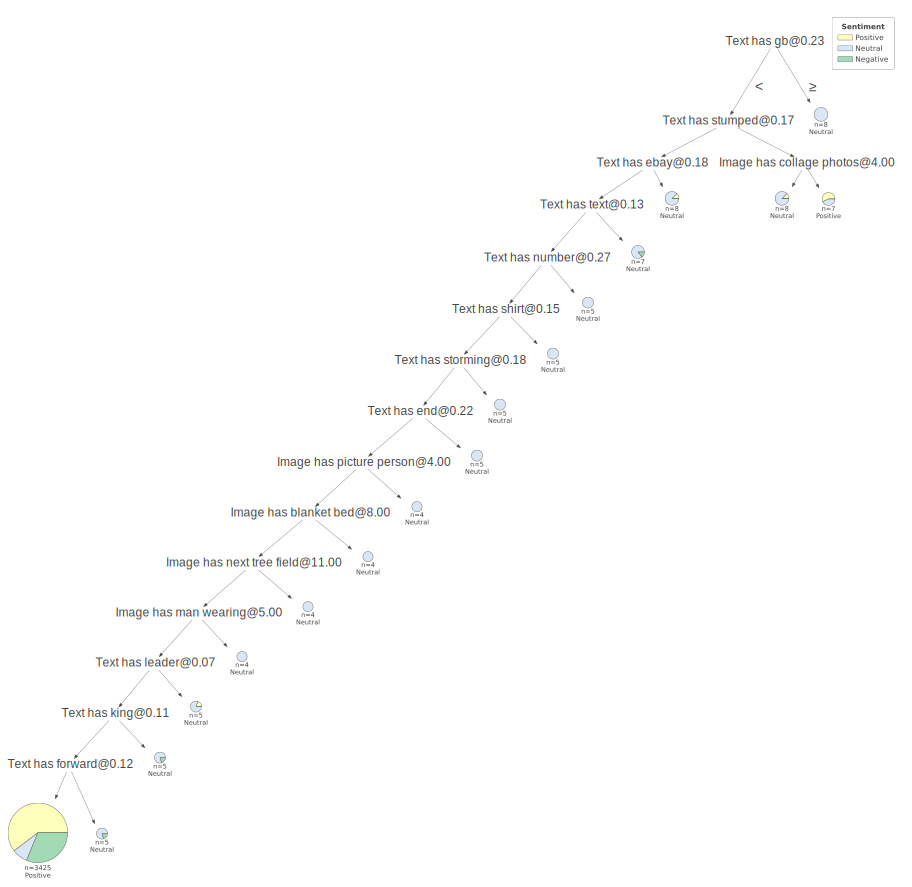

In [22]:
viz_model.view(fancy=False)

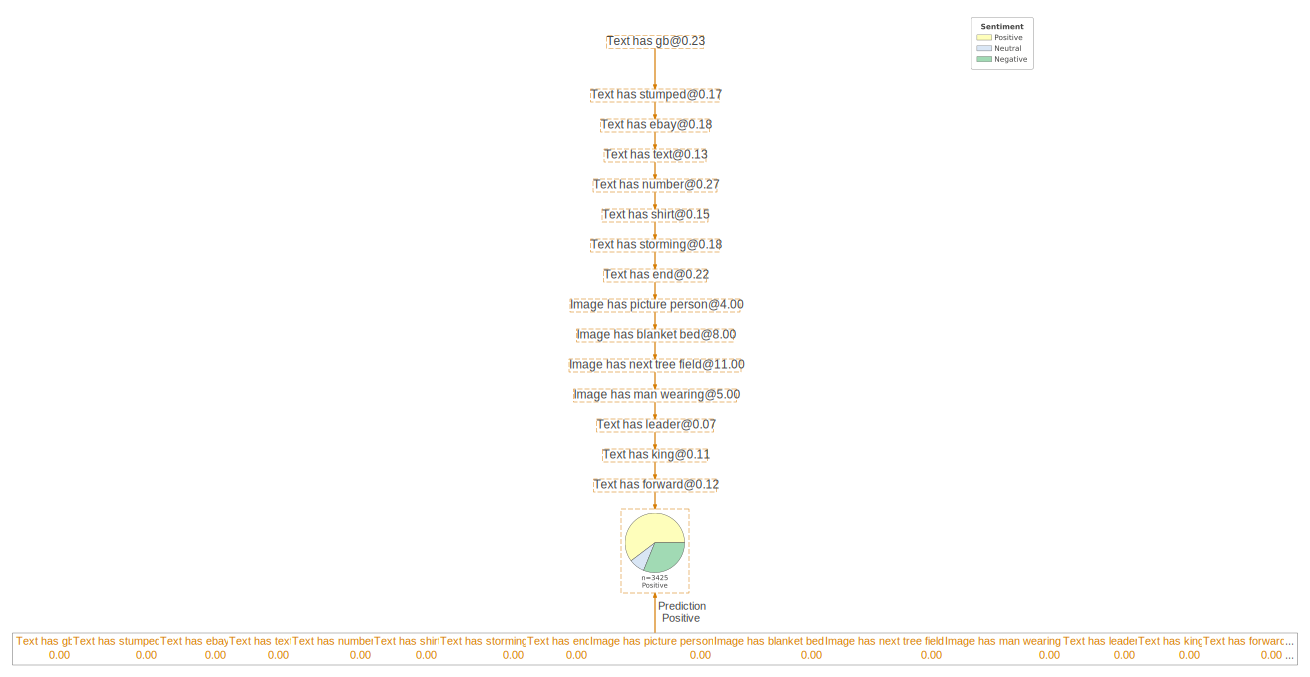

In [23]:
# Showing Only the Path taken

viz_model.view(x = X_test.values[10],
               fancy=False,
               show_just_path=True)

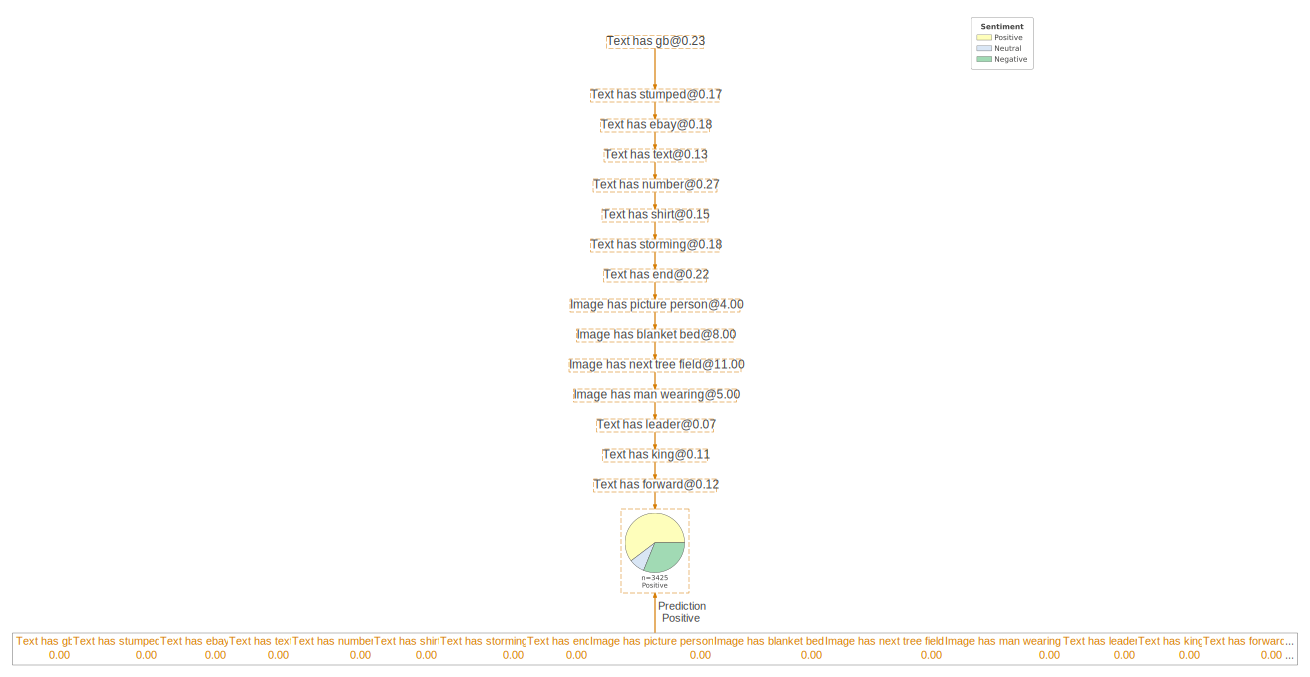

In [24]:
# Showing Only the Path taken

viz_model.view(x = X_test.values[150],
               fancy=False,
               show_just_path=True)